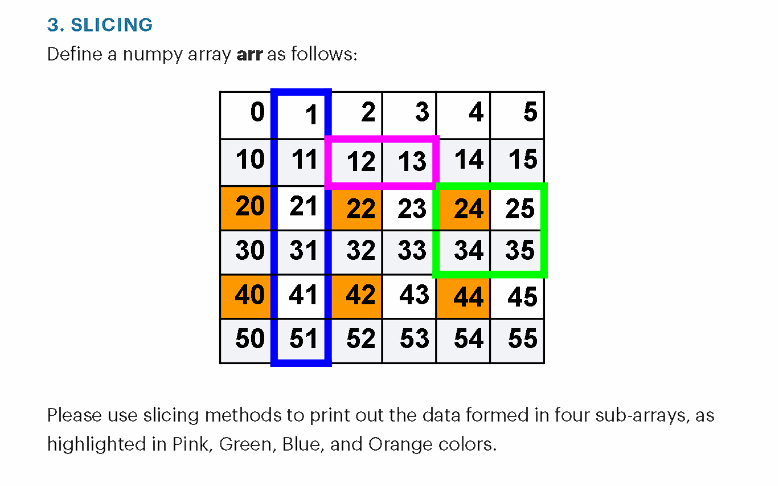

In [ ]:
# 1. Read the entire question carefully and identify the input, output, and constraints.
    #input: 6 x 6 array is the input
    #output: 4 sliced sub-arrays
# -------------------------------------------------------------------------------------------------------------------------
# 2. Think about the approach yourself and write down your idea or pseudocode before using AI.
    #
    #


# 3. Try solving it on your own for at least 10–15 minutes.
# 4. If you're stuck, ask Cursor for hints or explanations first—not the complete solution.
# 5. If you do use Cursor's solution, make sure you understand every line and can explain it in your own words.

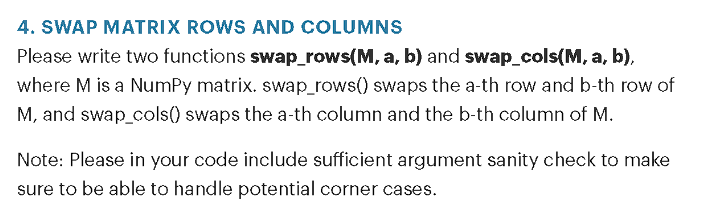

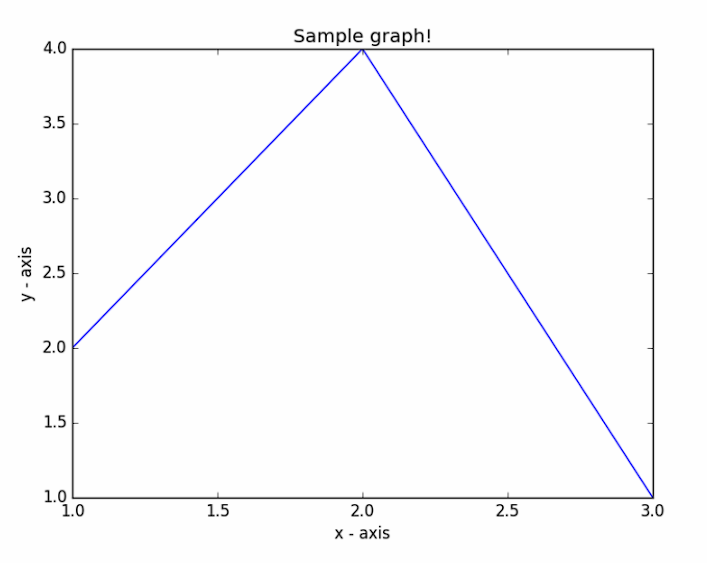

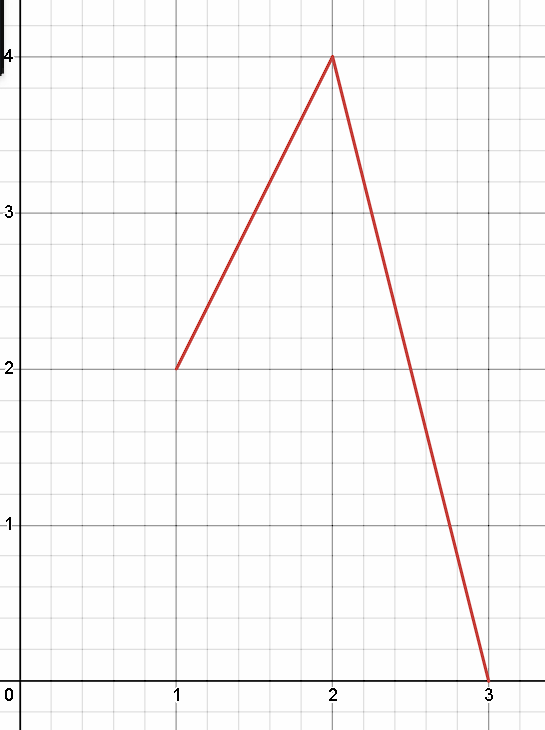

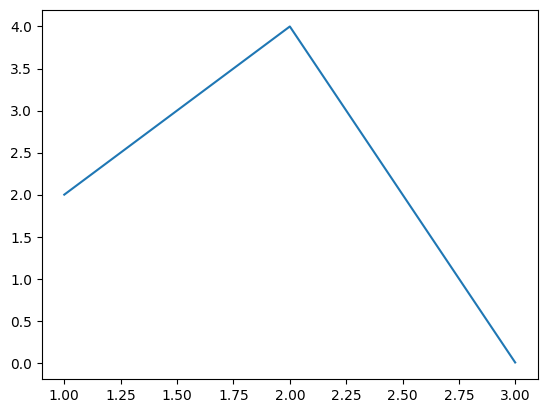

In [18]:
import numpy as np
import matplotlib.pyplot as plt

xs = np.arange(1, 3, 0.001)
# y = []
# for x in xs:
#     if x <= 2:
#         y.append(2 * (x - 1) + 2)
#     else:
#         y.append(-4 * (x - 3))

# --------------------------------------------------------------

y = np.empty_like(xs)
y[xs <= 2] = 2 * (xs[xs <=2 ] - 1) + 2
y[xs > 2] = -4 * (xs[xs > 2] - 3)

plt.plot(xs, y)
plt.show()

Brute-force optimal parameters: a = 2.000, b = -1.000


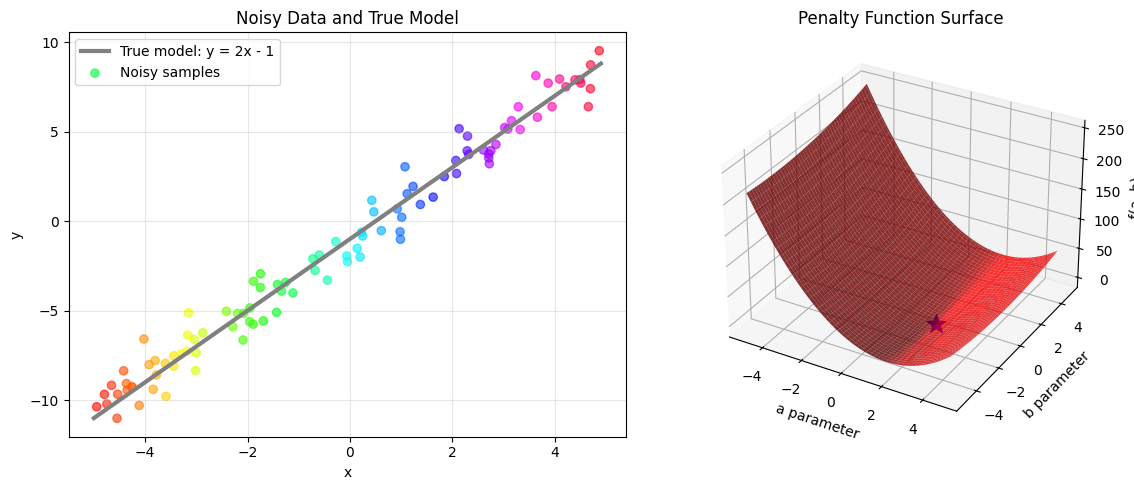

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d

# Set random seed for reproducibility
np.random.seed(42)

# Generate noisy samples from the true model: y = 2x - 1
sample_count = 100
x_sample = 10*np.random.random(sample_count)-5
y_sample = 2*x_sample - 1 + np.random.normal(0, 1.0, sample_count)

# Define the penalty function
def penalty(para_a, para_b):
    squares = (y_sample - para_a*x_sample - para_b)**2
    return 1/2/sample_count*np.sum(squares)

# Create figure with two subplots
fig = plt.figure(figsize=(12, 5))

# Subplot 1: Show the noisy samples and true line
ax1 = fig.add_subplot(1,2,1)
x = np.arange(-5, 5, 0.1)
y = 2*x - 1
ax1.plot(x, y, 'gray', linewidth = 3, label='True model: y = 2x - 1')
ax1.scatter(x_sample, y_sample, c = x_sample, cmap = 'hsv', alpha=0.6, label='Noisy samples')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title('Noisy Data and True Model')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Subplot 2: Show the penalty function surface
ax2 = fig.add_subplot(1,2,2, projection = '3d')

# Create a grid of (a, b) values
a_arr, b_arr = np.meshgrid(np.arange(-5, 5, 0.1), np.arange(-5, 5, 0.1))

# Compute penalty function value for each (a, b) pair
func_value = np.zeros(a_arr.shape)
for ax in range(a_arr.shape[0]):
    for ay in range(a_arr.shape[1]):
        func_value[ax, ay] = penalty(a_arr[ax, ay], b_arr[ax, ay])

# Plot the surface
ax2.plot_surface(a_arr, b_arr, func_value, color = 'red', alpha = 0.8)
ax2.set_xlabel('a parameter')
ax2.set_ylabel('b parameter')
ax2.set_zlabel('f(a, b)')
ax2.set_title('Penalty Function Surface')

# Find and mark the minimum value
optimal_x, optimal_y = np.where(func_value == np.amin(func_value))
print(f"Brute-force optimal parameters: a = {a_arr[optimal_x, optimal_y][0]:.3f}, b = {b_arr[optimal_x, optimal_y][0]:.3f}")
ax2.scatter(a_arr[optimal_x, optimal_y], b_arr[optimal_x, optimal_y], 
    func_value[optimal_x, optimal_y], marker = '*', s=200, c='blue')

plt.tight_layout()
plt.show()

Learning rate 1e-05: Converged to a = -7.999, b = 8.000 in 1 steps
Learning rate 0.0001: Converged to a = 0.477, b = 6.129 in 2000 steps
Learning rate 0.1: Converged to a = 1.954, b = -1.006 in 66 steps
Learning rate 0.02: Converged to a = 1.956, b = -0.966 in 259 steps


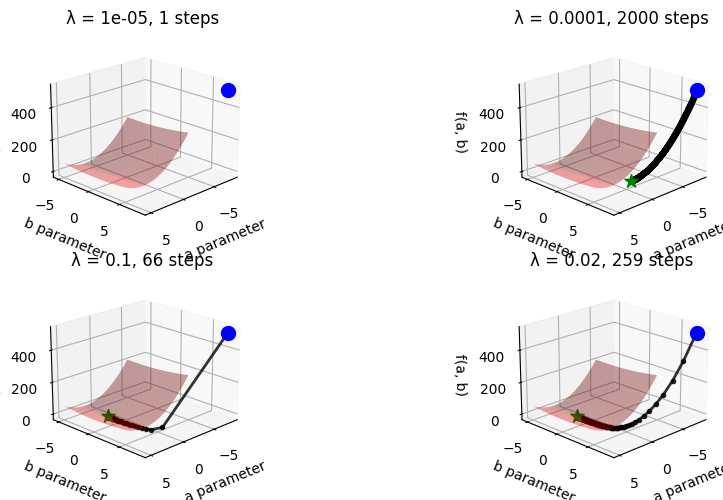

In [3]:
# Gradient descent implementation
def grad(aa):
    """Calculate gradient at point aa = [a, b]"""
    grad_aa = np.zeros(2)
    update_vector = (y_sample - aa[0] * x_sample - aa[1])
    grad_aa[0] = - 1/sample_count * x_sample.dot(update_vector)
    grad_aa[1] = - 1/sample_count * np.sum(update_vector)
    return grad_aa

# Visualization of gradient descent path
fig = plt.figure(figsize=(12, 5))

# Run gradient descent with different learning rates
learning_rates = [0.00001, 0.0001, 0.1, 0.02]
colors = ['blue', 'green', 'orange', 'red']

for idx, learn_rate in enumerate(learning_rates):
    ax = fig.add_subplot(2, 2, idx+1, projection='3d')
    
    # Plot the surface
    ax.plot_surface(a_arr, b_arr, func_value, color='red', alpha=0.4)
    
    # Initialize
    aa = np.array([-8, 8])  # Starting point
    delta = np.inf
    epsilon = 0.001
    step_count = 0
    max_steps = 2000
    
    # Store path for visualization
    path = [aa.copy()]
    
    # Gradient descent loop
    while delta > epsilon and step_count < max_steps:
        aa_next = aa - learn_rate * grad(aa)
        delta = np.linalg.norm(aa - aa_next)
        aa = aa_next
        step_count += 1
        path.append(aa.copy())
    
    # Plot the path
    path = np.array(path)
    z_path = [penalty(p[0], p[1]) for p in path]
    
    # Plot starting and ending points
    ax.scatter(path[0, 0], path[0, 1], z_path[0], c='blue', s=100, marker='o', label='Start')
    ax.scatter(path[-1, 0], path[-1, 1], z_path[-1], c='green', s=100, marker='*', label='End')
    
    # Plot the descent path
    ax.plot(path[:, 0], path[:, 1], z_path, 'ko-', linewidth=2, markersize=3, alpha=0.8)
    
    ax.set_xlabel('a parameter')
    ax.set_ylabel('b parameter')
    ax.set_zlabel('f(a, b)')
    ax.set_title(f'λ = {learn_rate}, {step_count} steps')
    ax.view_init(elev=20, azim=45)
    
    print(f"Learning rate {learn_rate}: Converged to a = {aa[0]:.3f}, b = {aa[1]:.3f} in {step_count} steps")

plt.tight_layout()
plt.show()

In [ ]:
# if lr is too high: Divergence
# if lr is too low: then the convergence will take too much steps
# if lr = 0.01: this converges too good